## Explicção Breve do Projeto
- Importação dos dados de FIDC pelo portal do CVM (Comissão de Valores Moobiliários) entre os meses de Setembro, Outubro e Novembro, para analisar anomalias nas transações desse fundo de investimento.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Criar um filtro para identificar as empresas envolvidas

In [ ]:
# --- PASSO 1: CONFIGURAÇÃO COM A NOVA TABELA ---
import pandas as pd
import numpy as np

# 1. Carregar a nova tabela (Aba de CNPJs e Raízes)
# Use o nome exato do arquivo que você subiu no Colab
caminho_csv = '/content/drive/MyDrive/dados-master/CNPJs_atualizado.xlsx'
df_relacoes = pd.read_excel(caminho_csv)

# 2. Criar dicionários de inteligência: Raiz -> Instituição e Raiz -> Status
# O .zfill(8) é vital para não perder os zeros à esquerda (ex: Reag 00360305)
mapeamento_grupos = dict(zip(
    df_relacoes['Raiz (8 dígitos)'].astype(str).str.zfill(8),
    df_relacoes['Instituição']
))

mapeamento_status = dict(zip(
    df_relacoes['Raiz (8 dígitos)'].astype(str).str.zfill(8),
    df_relacoes['Status / Situação Atual']
))

def identificar_grupo(cnpj):
    if pd.isna(cnpj): return 'Mercado'
    raiz = str(cnpj)[:8].zfill(8)
    return mapeamento_grupos.get(raiz, 'Mercado')

def identificar_status(cnpj):
    if pd.isna(cnpj): return 'Normal'
    raiz = str(cnpj)[:8].zfill(8)
    return mapeamento_status.get(raiz, 'Normal')

def limpar_cnpj(cnpj):
    return ''.join(filter(str.isdigit, str(cnpj))).zfill(14)

## 2. Pipeline de Extração Organizada (ETL)

In [ ]:
# --- PASSO 2: ETL (EXTRAÇÃO E CONSOLIDAÇÃO) ---

caminho_base = '/content/drive/MyDrive/dados-master'
# O padrão busca especificamente as pastas de 2025 (de 03 a 11)
padrao_arquivos = os.path.join(caminho_base, 'inf_mensal_fidc_2025*', '*tab_*.csv')
arquivos = glob.glob(padrao_arquivos)

# Dicionário para organizar os dados por tipo de tabela
tabelas_consolidadas = {}

print(f"Iniciando a leitura de {len(arquivos)} arquivos...")

for arq in arquivos:
    nome_base = os.path.basename(arq)
    partes = nome_base.split('_')

    # Lógica de identificação do tipo da tabela (Ex: tab_I, tab_VII, tab_X_3)
    # Procuramos o índice do termo 'tab' para pegar ele e o próximo identificador
    try:
        idx_tab = partes.index('tab')
        tipo_tab = f"{partes[idx_tab]}_{partes[idx_tab+1]}"
        # Caso especial para as tabelas da série X que possuem sub-índices (X.1, X.3, etc)
        if tipo_tab == 'tab_X' and len(partes) > idx_tab + 2 and partes[idx_tab+2].isdigit():
            tipo_tab = f"tab_X_{partes[idx_tab+2]}"
    except (ValueError, IndexError):
        tipo_tab = 'outros'

    # Leitura do CSV com as configurações da CVM
    df_temp = pd.read_csv(arq, sep=';', encoding='iso-8859-1', low_memory=False)

    # --- NORMALIZAÇÃO IMEDIATA (Essencial para o Merge futuro) ---

    # 1. Padronizar CNPJs (Remove pontos, barras e traços)
    if 'CNPJ_FUNDO_CLASSE' in df_temp.columns:
        df_temp['CNPJ_FUNDO_CLASSE'] = df_temp['CNPJ_FUNDO_CLASSE'].apply(limpar_cnpj)

    if 'CNPJ_FUNDO' in df_temp.columns: # Nome usado em algumas tabelas da série X
        df_temp['CNPJ_FUNDO'] = df_temp['CNPJ_FUNDO'].apply(limpar_cnpj)

    if 'CNPJ_ADMIN' in df_temp.columns:
        df_temp['CNPJ_ADMIN'] = df_temp['CNPJ_ADMIN'].apply(limpar_cnpj)

    # 2. Padronizar Datas (Transforma string em objeto datetime)
    if 'DT_COMPTC' in df_temp.columns:
        df_temp['DT_COMPTC'] = pd.to_datetime(df_temp['DT_COMPTC'])

    # Agrupar no dicionário
    if tipo_tab not in tabelas_consolidadas:
        tabelas_consolidadas[tipo_tab] = []
    tabelas_consolidadas[tipo_tab].append(df_temp)

# Concatenar todos os meses de cada categoria em um único DataFrame
print("\n--- Resumo da Consolidação de 2025 ---")
for tipo in sorted(tabelas_consolidadas.keys()):
    tabelas_consolidadas[tipo] = pd.concat(tabelas_consolidadas[tipo], ignore_index=True)
    print(f"Tabela {tipo.ljust(8)} | Total de Linhas: {len(tabelas_consolidadas[tipo])}")

print("\nPasso 2 concluído com sucesso!")

Iniciando a leitura de 153 arquivos...

--- Resumo da Consolidação de 2025 ---
Tabela tab_I    | Total de Linhas: 29876
Tabela tab_II   | Total de Linhas: 29876
Tabela tab_III  | Total de Linhas: 29876
Tabela tab_IV   | Total de Linhas: 29876
Tabela tab_IX   | Total de Linhas: 29876
Tabela tab_V    | Total de Linhas: 29876
Tabela tab_VI   | Total de Linhas: 29876
Tabela tab_VII  | Total de Linhas: 29876
Tabela tab_X    | Total de Linhas: 29876
Tabela tab_X_1  | Total de Linhas: 128499
Tabela tab_X_2  | Total de Linhas: 98324
Tabela tab_X_3  | Total de Linhas: 98253
Tabela tab_X_4  | Total de Linhas: 372198
Tabela tab_X_5  | Total de Linhas: 29876
Tabela tab_X_6  | Total de Linhas: 95700
Tabela tab_X_7  | Total de Linhas: 29876

Passo 2 concluído com sucesso!


## 3. O "Master Join" (Transformação)

In [ ]:
# --- PASSO 3 FINAL — baseado nos metadados oficiais da CVM ---

chaves = ['CNPJ_FUNDO_CLASSE', 'DT_COMPTC']

# ── 1. Base: Tab I + Tab IV ──────────────────────────────────────────────────
df_master = pd.merge(
    tabelas_consolidadas['tab_I'][[
        'CNPJ_FUNDO_CLASSE', 'DT_COMPTC', 'CNPJ_ADMIN', 'DENOM_SOCIAL',
        'TAB_I2A2_VL_CRED_VENC_INAD',
        'TAB_I2A3_VL_CRED_INAD',
        'TAB_I2B2_VL_CRED_VENC_INAD',
        'TAB_I2B3_VL_CRED_INAD',
        'TAB_I2A12_CPF_CNPJ_CEDENTE_1',
        'TAB_I2A12_CPF_CNPJ_CEDENTE_2',
        'TAB_I2A12_CPF_CNPJ_CEDENTE_3',
        'TAB_I2A12_PR_CEDENTE_1',
    ]],
    tabelas_consolidadas['tab_IV'][chaves + ['TAB_IV_A_VL_PL']],
    on=chaves, how='left'
)

# ── 2. Tab VII ───────────────────────────────────────────────────────────────
df_master = pd.merge(
    df_master,
    tabelas_consolidadas['tab_VII'][chaves + [
        'TAB_VII_A1_2_VL_DIRCRED_RISCO',
        'TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO',
        'TAB_VII_C_2_VL_SUBST',
        'TAB_VII_D_2_VL_RECOMPRA',
        'TAB_VII_B1_2_VL_CEDENTE',
    ]],
    on=chaves, how='left'
)

# ── 3. Tab X.5 ───────────────────────────────────────────────────────────────
if 'tab_X_5' in tabelas_consolidadas:
    df_master = pd.merge(
        df_master,
        tabelas_consolidadas['tab_X_5'][chaves + [
            'TAB_X_VL_LIQUIDEZ_0',
            'TAB_X_VL_LIQUIDEZ_30',
            'TAB_X_VL_LIQUIDEZ_MAIOR_360',
        ]],
        on=chaves, how='left'
    )

# ── 4. Tab X.6 ───────────────────────────────────────────────────────────────
if 'tab_X_6' in tabelas_consolidadas:
    cols_x6 = tabelas_consolidadas['tab_X_6'].columns
    col_cnpj_x6 = 'CNPJ_FUNDO' if 'CNPJ_FUNDO' in cols_x6 else 'CNPJ_FUNDO_CLASSE'
    df_x6 = tabelas_consolidadas['tab_X_6'].copy()
    df_x6[col_cnpj_x6] = df_x6[col_cnpj_x6].apply(limpar_cnpj)
    df_x6['TAB_X_PR_DESVIO_DESEMP'] = (
        pd.to_numeric(df_x6['TAB_X_PR_DESEMP_REAL'].astype(str).str.replace(',','.'), errors='coerce') -
        pd.to_numeric(df_x6['TAB_X_PR_DESEMP_ESPERADO'].astype(str).str.replace(',','.'), errors='coerce')
    ).abs()
    df_x6_agg = df_x6.groupby([col_cnpj_x6, 'DT_COMPTC'], as_index=False)['TAB_X_PR_DESVIO_DESEMP'].max()
    df_master = pd.merge(df_master, df_x6_agg,
                         left_on=['CNPJ_FUNDO_CLASSE', 'DT_COMPTC'],
                         right_on=[col_cnpj_x6, 'DT_COMPTC'], how='left')
    if col_cnpj_x6 != 'CNPJ_FUNDO_CLASSE':
        df_master.drop(columns=[col_cnpj_x6], inplace=True, errors='ignore')

# ── 5. Tab X.3 ───────────────────────────────────────────────────────────────
if 'tab_X_3' in tabelas_consolidadas:
    df_x3 = tabelas_consolidadas['tab_X_3'].copy()
    col_cnpj_x3 = 'CNPJ_FUNDO' if 'CNPJ_FUNDO' in df_x3.columns else 'CNPJ_FUNDO_CLASSE'
    df_x3[col_cnpj_x3] = df_x3[col_cnpj_x3].apply(limpar_cnpj)
    df_x3['VL_COTA_NUM'] = pd.to_numeric(
        df_x3['TAB_X_VL_RENTAB_MES'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df_x3 = df_x3[df_x3['VL_COTA_NUM'].between(0.50, 100_000)].copy()
    df_x3_agg = (
        df_x3[df_x3['TAB_X_CLASSE_SERIE'].str.contains('Senior', case=False, na=False)]
        .groupby([col_cnpj_x3, 'DT_COMPTC'], as_index=False)['VL_COTA_NUM'].max()
    )
    df_x3_agg = df_x3_agg.sort_values([col_cnpj_x3, 'DT_COMPTC'])
    df_x3_agg['TAB_X_VL_RENTAB_MES'] = (
        df_x3_agg.groupby(col_cnpj_x3)['VL_COTA_NUM'].pct_change(fill_method=None)
    )
    df_x3_agg.loc[df_x3_agg['TAB_X_VL_RENTAB_MES'].abs() > 0.30, 'TAB_X_VL_RENTAB_MES'] = np.nan
    df_master = df_master.drop(columns=['TAB_X_VL_RENTAB_MES'], errors='ignore')
    df_master = pd.merge(df_master,
                         df_x3_agg[[col_cnpj_x3, 'DT_COMPTC', 'TAB_X_VL_RENTAB_MES']],
                         left_on=['CNPJ_FUNDO_CLASSE', 'DT_COMPTC'],
                         right_on=[col_cnpj_x3, 'DT_COMPTC'], how='left')
    if col_cnpj_x3 != 'CNPJ_FUNDO_CLASSE':
        df_master.drop(columns=[col_cnpj_x3], inplace=True, errors='ignore')

# ── 6. Normalizar colunas numéricas ──────────────────────────────────────────
cols_numericas = [
    'TAB_VII_A1_2_VL_DIRCRED_RISCO', 'TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO',
    'TAB_VII_C_2_VL_SUBST', 'TAB_VII_D_2_VL_RECOMPRA', 'TAB_VII_B1_2_VL_CEDENTE',
    'TAB_I2A2_VL_CRED_VENC_INAD', 'TAB_I2A3_VL_CRED_INAD',
    'TAB_I2B2_VL_CRED_VENC_INAD', 'TAB_I2B3_VL_CRED_INAD',
]
for col in cols_numericas:
    if col in df_master.columns:
        df_master[col] = pd.to_numeric(
            df_master[col].astype(str).str.replace(',', '.'), errors='coerce'
        ).fillna(0)

# ── 7. Mapeamento de grupos em cascata ───────────────────────────────────────
df_master['grupo_economico'] = df_master['CNPJ_ADMIN'].apply(identificar_grupo)

mask = df_master['grupo_economico'] == 'Mercado'
df_master.loc[mask, 'grupo_economico'] = (
    df_master.loc[mask, 'CNPJ_FUNDO_CLASSE'].apply(identificar_grupo)
)

for col_ced in ['TAB_I2A12_CPF_CNPJ_CEDENTE_1',
                'TAB_I2A12_CPF_CNPJ_CEDENTE_2',
                'TAB_I2A12_CPF_CNPJ_CEDENTE_3']:
    if col_ced in df_master.columns:
        mask = df_master['grupo_economico'] == 'Mercado'
        df_master.loc[mask, 'grupo_economico'] = (
            df_master.loc[mask, col_ced]
            .apply(lambda x: identificar_grupo(
                str(int(float(x))).zfill(14) if pd.notna(x) and float(x) > 0 else None
            ))
        )

# ── 8. Features originais ────────────────────────────────────────────────────
pl = df_master['TAB_IV_A_VL_PL']

df_master['movimentacao_total_taxa'] = np.where(
    pl > 0,
    (df_master['TAB_VII_A1_2_VL_DIRCRED_RISCO']
     + df_master['TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO']
     + df_master['TAB_VII_C_2_VL_SUBST']
     + df_master['TAB_VII_D_2_VL_RECOMPRA']) / pl,
    0
)

df_master['vl_inad_total'] = (
    df_master['TAB_I2A2_VL_CRED_VENC_INAD']
    + df_master['TAB_I2A3_VL_CRED_INAD']
    + df_master['TAB_I2B2_VL_CRED_VENC_INAD']
    + df_master['TAB_I2B3_VL_CRED_INAD']
)
df_master['taxa_inadimplencia'] = np.where(pl > 0, df_master['vl_inad_total'] / pl, 0)

df_master['concentracao_cedente'] = pd.to_numeric(
    df_master['TAB_I2A12_PR_CEDENTE_1'].astype(str).str.replace(',', '.'),
    errors='coerce'
).fillna(0)

# ── 9. Features adicionais (Ajustes 1 e 2) ───────────────────────────────────

# Aquisições separadas das devoluções ao cedente
df_master['taxa_aquisicao'] = np.where(
    pl > 0,
    (df_master['TAB_VII_A1_2_VL_DIRCRED_RISCO']
     + df_master['TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO']) / pl,
    0
)

# Devoluções ao cedente / PL — alta devolução = cedente recomprando ativos problemáticos
df_master['taxa_devolucao_cedente'] = np.where(
    pl > 0,
    df_master['TAB_VII_B1_2_VL_CEDENTE'] / pl,
    0
)

# Ratio inadimplência / giro — TI alta com TM baixa = fundo parou de renovar carteira
# TI baixa com TM alta = estão substituindo inadimplentes antes de declarar
df_master['ratio_inad_giro'] = np.where(
    df_master['movimentacao_total_taxa'] > 0,
    df_master['taxa_inadimplencia'] / df_master['movimentacao_total_taxa'],
    0
)

# ── Após o cálculo de ratio_inad_giro, antes do log de cobertura ──────────────

# Remover observações com PL < R$ 1.000 — dados corrompidos (ex: PL = R$ 0,01)
# Esses registros geram ratios na casa dos milhões e distorcem médias e o modelo
n_antes = len(df_master)
df_master = df_master[df_master['TAB_IV_A_VL_PL'] >= 1_000].copy()
print(f"Removidos por PL < R$ 1.000: {n_antes - len(df_master):,} registros")
print(f"Restantes: {len(df_master):,}")

# Confirmar que os valores estão limpos agora
print("\nmovimentacao_total_taxa após limpeza:")
print(df_master['movimentacao_total_taxa'].quantile([0.5, 0.75, 0.9, 0.99]).round(4))
print("\ntaxa_inadimplencia após limpeza:")
print(df_master['taxa_inadimplencia'].quantile([0.5, 0.75, 0.9, 0.99]).round(4))


# Logo após: df_master = df_master[df_master['TAB_IV_A_VL_PL'] >= 1_000].copy()

# Corrigir concentracao_cedente — percentual não pode passar de 100%
# Valores acima de 100 são erros de escala na declaração (ex: 9000 em vez de 90.00)
df_master.loc[df_master['concentracao_cedente'] > 100, 'concentracao_cedente'] = np.nan
df_master['concentracao_cedente'] = df_master['concentracao_cedente'].fillna(0)

# Corrigir ratio_inad_giro — ratio acima de 100 não tem interpretação forense útil
# Indica denominador (TM) muito pequeno, não anomalia real
df_master.loc[df_master['ratio_inad_giro'] > 100, 'ratio_inad_giro'] = 0

# ── 10. Log de cobertura ──────────────────────────────────────────────────────
print("=== Cobertura das features por grupo ===")
for grupo in ['Mercado', 'Master S/A Corretora (CTVB)',
              'Trustee DTVM Ltda.', 'Reag Trust DTVM S.A.']:
    sub = df_master[df_master['grupo_economico'] == grupo]
    if len(sub) == 0:
        continue
    print(f"\n{grupo} ({len(sub):,} linhas):")
    print(f"  TM>0  : {(sub['movimentacao_total_taxa']    > 0).sum():,}  mean={sub['movimentacao_total_taxa'].mean():.4f}")
    print(f"  TI>0  : {(sub['taxa_inadimplencia']         > 0).sum():,}  mean={sub['taxa_inadimplencia'].mean():.4f}")
    print(f"  CC>0  : {(sub['concentracao_cedente']        > 0).sum():,}  mean={sub['concentracao_cedente'].mean():.2f}%")
    print(f"  ACQ>0 : {(sub['taxa_aquisicao']              > 0).sum():,}  mean={sub['taxa_aquisicao'].mean():.4f}")
    print(f"  DEV>0 : {(sub['taxa_devolucao_cedente']      > 0).sum():,}  mean={sub['taxa_devolucao_cedente'].mean():.4f}")
    print(f"  RIG>0 : {(sub['ratio_inad_giro']             > 0).sum():,}  mean={sub['ratio_inad_giro'].mean():.4f}")

print(f"\nTotal df_master: {len(df_master):,} linhas | "
      f"{df_master['CNPJ_FUNDO_CLASSE'].nunique():,} fundos")
print(df_master[df_master['grupo_economico'] != 'Mercado']['grupo_economico'].value_counts())

Removidos por PL < R$ 1.000: 787 registros
Restantes: 29,215

movimentacao_total_taxa após limpeza:
0.50    0.0000
0.75    0.2238
0.90    0.5690
0.99    1.2334
Name: movimentacao_total_taxa, dtype: float64

taxa_inadimplencia após limpeza:
0.50     0.0000
0.75     0.0970
0.90     0.4471
0.99    13.7624
Name: taxa_inadimplencia, dtype: float64
=== Cobertura das features por grupo ===

Mercado (26,341 linhas):
  TM>0  : 12,100  mean=0.2978
  TI>0  : 12,406  mean=2.1077
  CC>0  : 7,858  mean=16.47%
  ACQ>0 : 11,917  mean=0.1801
  DEV>0 : 15  mean=0.0001
  RIG>0 : 9,095  mean=0.8313

Master S/A Corretora (CTVB) (504 linhas):
  TM>0  : 288  mean=0.2060
  TI>0  : 296  mean=0.3107
  CC>0  : 180  mean=17.85%
  ACQ>0 : 288  mean=0.2060
  DEV>0 : 0  mean=0.0000
  RIG>0 : 235  mean=1.0509

Trustee DTVM Ltda. (665 linhas):
  TM>0  : 133  mean=1.3683
  TI>0  : 175  mean=1.4561
  CC>0  : 7  mean=0.81%
  ACQ>0 : 133  mean=1.3683
  DEV>0 : 0  mean=0.0000
  RIG>0 : 76  mean=0.2090

Reag Trust DTVM S.A.

## 4. Engenharia de Atributos e Detecção de Anomalias

In [ ]:
# --- PASSO 4 FINAL ---
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

features = ['movimentacao_total_taxa', 'taxa_inadimplencia', 'concentracao_cedente']

# 1. Filtro de linhas válidas — PL >= 1 milhão elimina fundos minúsculos
mask_valido = df_master[features].notna().all(axis=1)
mask_valido &= df_master['TAB_IV_A_VL_PL'] >= 1_000_000

X_clean = df_master.loc[mask_valido, features].copy()
print(f"Linhas válidas (PL >= 1M): {mask_valido.sum():,}")
print(f"Descartadas              : {(~mask_valido).sum():,}")

# 2. Máscara do mercado
mask_mercado = df_master.loc[mask_valido, 'grupo_economico'] == 'Mercado'
print(f"\nTreino (mercado)     : {mask_mercado.sum():,}")
print(f"Score (investigados) : {(~mask_mercado).sum():,}")

# 3. Winsorização — cortar extremos usando p1 e p99 do mercado
print("\nLimites de winsorização (p1–p99 do mercado):")
for feat in features:
    p01 = X_clean.loc[mask_mercado, feat].quantile(0.01)
    p99 = X_clean.loc[mask_mercado, feat].quantile(0.99)
    X_clean[feat] = X_clean[feat].clip(lower=p01, upper=p99)
    print(f"  {feat:<35} [{p01:.4f}, {p99:.4f}]")

# 4. Scaler — fit só no mercado
scaler = StandardScaler()
scaler.fit(X_clean[mask_mercado])
X_scaled = scaler.transform(X_clean)

print("\nParâmetros do scaler (μ, σ):")
for feat, mu, sigma in zip(features, scaler.mean_, scaler.scale_):
    print(f"  {feat:<35} μ={mu:.4f}  σ={sigma:.4f}")

# 5. Modelo — treina só no mercado
model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    max_samples=256,
    random_state=42
)
model.fit(X_scaled[mask_mercado])

# 6. Score normalizado 0..1
predicoes  = model.predict(X_scaled)
raw_scores = model.score_samples(X_scaled)
s_min, s_max = raw_scores.min(), raw_scores.max()
anomaly_score_01 = (raw_scores - s_max) / (s_min - s_max)

# 7. Gravar no df_master
df_master['anomaly_flag']   = np.nan
df_master['anomaly_score']  = np.nan
df_master['grau_suspeicao'] = np.nan
df_master['is_anomalia']    = 0

df_master.loc[mask_valido, 'anomaly_flag']   = predicoes
df_master.loc[mask_valido, 'anomaly_score']  = anomaly_score_01
df_master.loc[mask_valido, 'grau_suspeicao'] = anomaly_score_01
df_master.loc[mask_valido, 'is_anomalia']    = (predicoes == -1).astype(int)

# 8. Diagnóstico completo
print("\n--- Score de anomalia (distribuição) ---")
print(df_master['anomaly_score'].describe().round(4))

print("\n--- Anomalias por grupo ---")
resumo = (
    df_master[mask_valido]
    .groupby('grupo_economico')
    .agg(
        fundos      =('CNPJ_FUNDO_CLASSE', 'nunique'),
        score_medio =('anomaly_score',     'mean'),
        score_max   =('anomaly_score',     'max'),
        n_anomalias =('is_anomalia',       'sum'),
    )
    .sort_values('score_medio', ascending=False)
    .round(4)
)
print(resumo)

print("\n--- Top 10 fundos mais suspeitos ---")
ranking = (
    df_master[mask_valido]
    .groupby(['DENOM_SOCIAL', 'grupo_economico'])['anomaly_score']
    .mean()
    .reset_index()
    .nlargest(10, 'anomaly_score')
)
print(ranking.to_string(index=False))

print("\n--- Médias das features por grupo (após winsorização) ---")
df_check = df_master[mask_valido].copy()
df_check[features] = X_clean[features]   # versão winsorizadas
for grupo in ['Mercado', 'Master S/A Corretora (CTVB)',
              'Trustee DTVM Ltda.', 'Reag Trust DTVM S.A.']:
    sub = df_check[df_check['grupo_economico'] == grupo]
    if len(sub) == 0: continue
    print(f"\n{grupo}:")
    for feat in features:
        print(f"  {feat:<35} mean={sub[feat].mean():.4f}  "
              f"p75={sub[feat].quantile(0.75):.4f}  "
              f"max={sub[feat].max():.4f}")

Linhas válidas (PL >= 1M): 28,370
Descartadas              : 845

Treino (mercado)     : 25,619
Score (investigados) : 2,751

Limites de winsorização (p1–p99 do mercado):
  movimentacao_total_taxa             [0.0000, 1.2535]
  taxa_inadimplencia                  [0.0000, 5.4876]
  concentracao_cedente                [0.0000, 99.9600]

Parâmetros do scaler (μ, σ):
  movimentacao_total_taxa             μ=0.1690  σ=0.2768
  taxa_inadimplencia                  μ=0.1955  σ=0.6676
  concentracao_cedente                μ=16.7041  σ=31.2265

--- Score de anomalia (distribuição) ---
count    28370.0000
mean         0.2139
std          0.2212
min         -0.0000
25%          0.0000
50%          0.1916
75%          0.3651
max          1.0000
Name: anomaly_score, dtype: float64

--- Anomalias por grupo ---
                              fundos  score_medio  score_max  n_anomalias
grupo_economico                                                          
Banco Master S.A.                  1       0.

## 5. Gráficos

### Gráfico 1 — Evolução temporal do excesso de suspeição

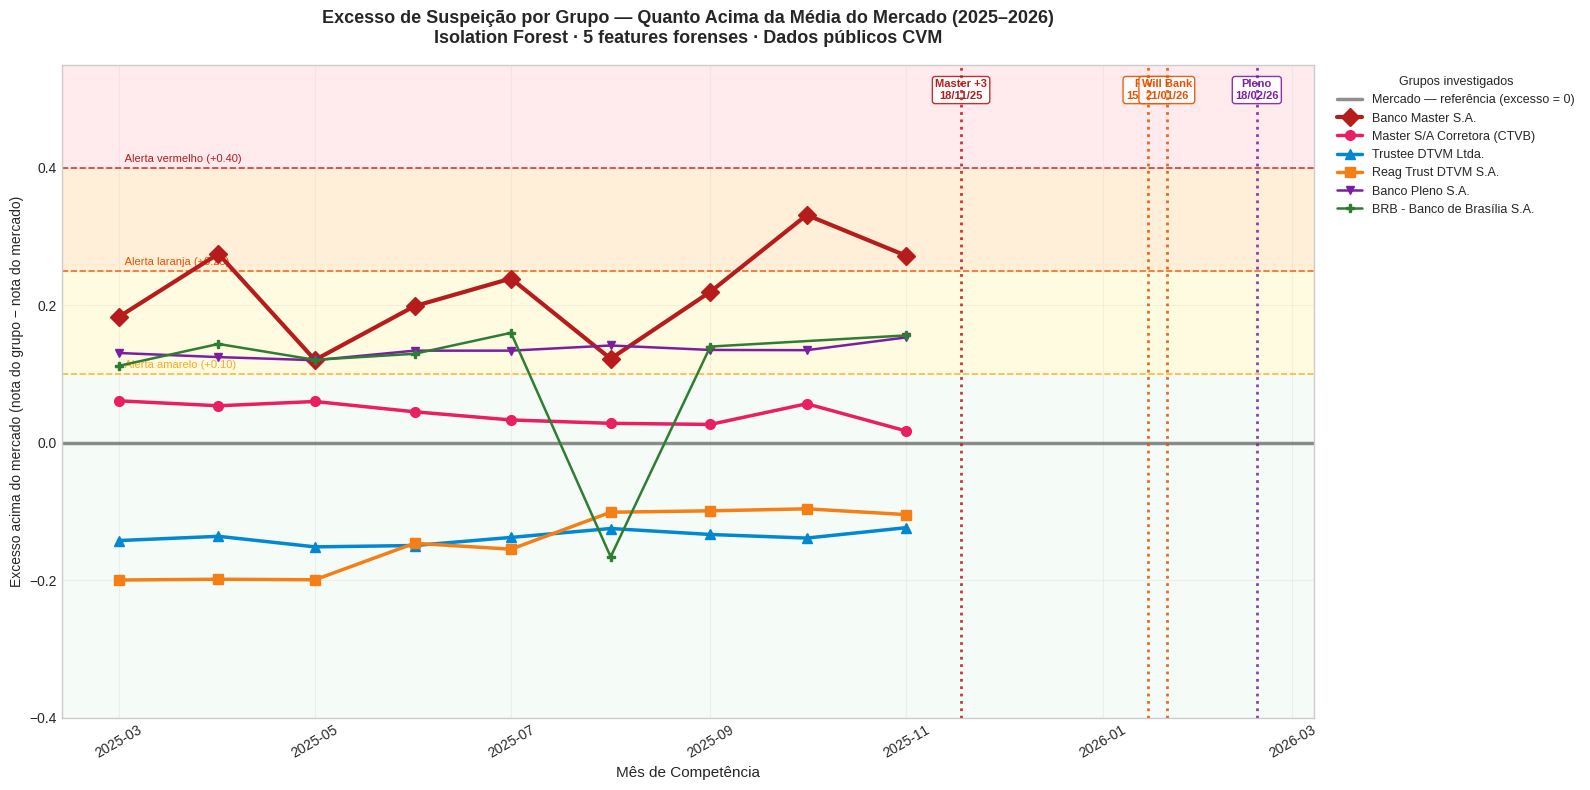

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

fig, ax = plt.subplots(figsize=(16, 8))

# Faixas de alerta
ax.axhspan(-0.5,  0.10, color='#E8F5E9', alpha=0.4, zorder=0)
ax.axhspan( 0.10, 0.25, color='#FFF9C4', alpha=0.5, zorder=0)
ax.axhspan( 0.25, 0.40, color='#FFE0B2', alpha=0.5, zorder=0)
ax.axhspan( 0.40, 0.80, color='#FFCDD2', alpha=0.4, zorder=0)

# Linhas de threshold
for nivel, cor, rotulo in [
    (0.10, '#F9A825', 'Alerta amarelo (+0.10)'),
    (0.25, '#E65100', 'Alerta laranja (+0.25)'),
    (0.40, '#B71C1C', 'Alerta vermelho (+0.40)'),
]:
    ax.axhline(nivel, color=cor, linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] != 0.0
            else pd.Timestamp('2025-03-01'),
            nivel + 0.006, f'  {rotulo}', fontsize=8, color=cor, va='bottom')

# Linha do mercado
ax.axhline(0, color='#444444', linestyle='-', linewidth=2.5, alpha=0.6,
           label='Mercado — referência (excesso = 0)', zorder=2)

# Calcular baseline e excesso de suspeição
baseline = (df_master[df_master['grupo_economico'] == 'Mercado']
            .groupby('DT_COMPTC')['grau_suspeicao'].mean())

df_master['excesso'] = (
    df_master['grau_suspeicao']
    - df_master['DT_COMPTC'].map(baseline).fillna(0)
)

grupos_cfg = {
    'Banco Master S.A.'           : ('#B71C1C', 'D', 3.0, 9),
    'Master S/A Corretora (CTVB)' : ('#E91E63', 'o', 2.5, 7),
    'Trustee DTVM Ltda.'          : ('#0288D1', '^', 2.5, 7),
    'Reag Trust DTVM S.A.'        : ('#F57F17', 's', 2.5, 7),
    'Banco Pleno S.A.'            : ('#7B1FA2', 'v', 1.8, 6),
    'BRB - Banco de Brasília S.A.': ('#2E7D32', 'P', 1.8, 6),
}

evolucao = (
    df_master[df_master['grupo_economico'].isin(grupos_cfg.keys())]
    .groupby([df_master['DT_COMPTC'].dt.to_period('M'), 'grupo_economico'])['excesso']
    .mean().unstack()
)
evolucao.index = evolucao.index.to_timestamp()

for grupo, (cor, mk, lw, ms) in grupos_cfg.items():
    if grupo not in evolucao.columns:
        continue
    serie = evolucao[grupo].dropna()
    ax.plot(serie.index, serie.values, color=cor, linewidth=lw,
            marker=mk, markersize=ms, label=grupo, zorder=5)

# Eventos de liquidação
eventos = {
    '2025-11-18': ('Master +3\n18/11/25', '#B71C1C'),
    '2026-01-15': ('Reag\n15/01/26',      '#E65100'),
    '2026-01-21': ('Will Bank\n21/01/26', '#E65100'),
    '2026-02-18': ('Pleno\n18/02/26',     '#7B1FA2'),
}
ylim_top = max(evolucao.max().max() * 1.15, 0.55)
ax.set_ylim(-0.4, ylim_top)

for data, (nome, cor_ev) in eventos.items():
    ts = pd.Timestamp(data)
    ax.axvline(ts, color=cor_ev, linestyle=':', linewidth=2.0, alpha=0.85, zorder=6)
    ax.text(ts, ylim_top * 0.91, nome, fontsize=8, ha='center',
            color=cor_ev, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=cor_ev, alpha=0.9))

ax.set_title(
    'Excesso de Suspeição por Grupo — Quanto Acima da Média do Mercado (2025–2026)\n'
    'Isolation Forest · 5 features forenses · Dados públicos CVM',
    fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Mês de Competência', fontsize=11)
ax.set_ylabel('Excesso acima do mercado (nota do grupo − nota do mercado)', fontsize=10)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9,
          title='Grupos investigados', title_fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico1_excesso_suspeicao.png',
            dpi=150, bbox_inches='tight')
plt.show()

- Este gráfico mostra, mês a mês, o quanto cada grupo investigado ficou acima ou abaixo da média do mercado em termos de comportamento suspeito. O zero representa o mercado normal. Linhas acima do zero indicam que o grupo estava se comportando de forma mais anômala que os demais fundos naquele mês. As faixas coloridas de fundo funcionam como um semáforo: verde é monitoramento rotineiro, amarelo pede auditoria, laranja exige suspensão de recompras, vermelho indica necessidade de intervenção imediata. As linhas verticais pontilhadas marcam as datas em que o Banco Central efetivamente fechou cada instituição. O ponto mais importante do gráfico é que o Banco Master S.A. já operava na faixa laranja meses antes de ser liquidado — o modelo sinalizava o problema com antecedência.


### Gráfico 2 — Ranking dos 20 fundos mais suspeitos

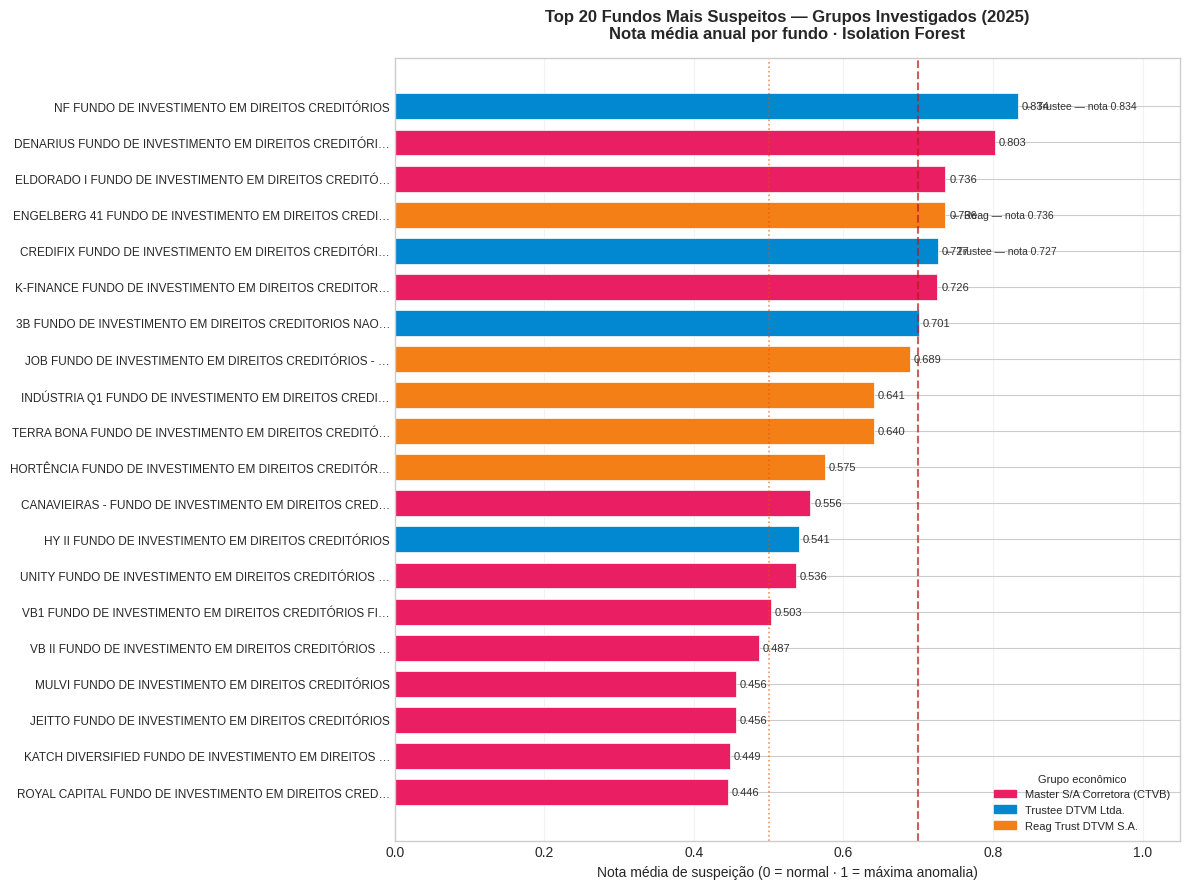

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

# Preparar dados — top 20 fundos por nota média
df_rank = (
    df_master[df_master['grupo_economico'] != 'Mercado']
    .groupby(['DENOM_SOCIAL', 'grupo_economico'])['anomaly_score']
    .mean().reset_index()
    .nlargest(20, 'anomaly_score')
    .reset_index(drop=True)
)

cores_grupo = {
    'Master S/A Corretora (CTVB)' : '#E91E63',
    'Banco Master S.A.'           : '#B71C1C',
    'Trustee DTVM Ltda.'          : '#0288D1',
    'Reag Trust DTVM S.A.'        : '#F57F17',
    'Banco Pleno S.A.'            : '#7B1FA2',
    'BRB - Banco de Brasília S.A.': '#2E7D32',
}
cores_barras = [cores_grupo.get(g, '#888888') for g in df_rank['grupo_economico']]
nomes = [n[:52] + '…' if len(n) > 52 else n for n in df_rank['DENOM_SOCIAL']]

barras = ax.barh(range(len(df_rank)), df_rank['anomaly_score'],
                 color=cores_barras, edgecolor='white', linewidth=0.5,
                 height=0.72)
ax.set_yticks(range(len(df_rank)))
ax.set_yticklabels(nomes, fontsize=8.5)
ax.invert_yaxis()

# Valor no final de cada barra
for i, (barra, val) in enumerate(zip(barras, df_rank['anomaly_score'])):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8, color='#333333')

# Linha de threshold crítico
ax.axvline(0.70, color='#B71C1C', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Limiar crítico (0.70)')
ax.axvline(0.50, color='#E65100', linestyle=':', linewidth=1.2, alpha=0.6,
           label='Limiar elevado (0.50)')

# Anotações nos fundos de destaque
destaques = {
    'NF FUNDO': 'Trustee — nota 0.834',
    'ENGELBERG': 'Reag — nota 0.736',
    'CREDIFIX':  'Trustee — nota 0.727',
}
for i, nome in enumerate(df_rank['DENOM_SOCIAL']):
    for chave, texto in destaques.items():
        if chave in nome:
            ax.annotate(f'  ← {texto}',
                        xy=(df_rank.loc[i,'anomaly_score'], i),
                        fontsize=7.5, color='#333333', va='center')

# Legenda de grupos
handles = [mpatches.Patch(color=c, label=g) for g, c in cores_grupo.items()
           if g in df_rank['grupo_economico'].values]
ax.legend(handles=handles, loc='lower right', fontsize=8,
          title='Grupo econômico', title_fontsize=8)

ax.set_xlabel('Nota média de suspeição (0 = normal · 1 = máxima anomalia)', fontsize=10)
ax.set_title('Top 20 Fundos Mais Suspeitos — Grupos Investigados (2025)\n'
             'Nota média anual por fundo · Isolation Forest',
             fontsize=12, fontweight='bold', pad=14)
ax.grid(axis='x', alpha=0.25)
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico2_ranking_fundos.png',
            dpi=150, bbox_inches='tight')
plt.show()

- Este gráfico lista os 20 fundos com maior nota de suspeição média ao ano, ordenados do mais anômalo para o menos. Cada barra representa um fundo, e a cor indica a qual grupo econômico ele pertence. A nota vai de 0 a 1 — quanto mais à direita, mais fora do padrão normal o fundo se comportou ao longo de 2025. A linha tracejada vermelha marca o limiar crítico de 0.70, acima do qual o comportamento é considerado estatisticamente extremo. Os três fundos de destaque — NF FUNDO (0.834), ENGELBERG 41 (0.736) e CREDIFIX (0.727) — são administrados pela Trustee e pela Reag, grupos que na análise agregada pareciam normais, mas cujos fundos individuais revelam anomalia comparável ao Banco Master.

### Gráfico 3 — Mapa forense TM × TI


/tmp/ipykernel_21790/1099160151.py:103: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.savefig('/content/drive/MyDrive/dados-master/grafico3_mapa_forense_subplots.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


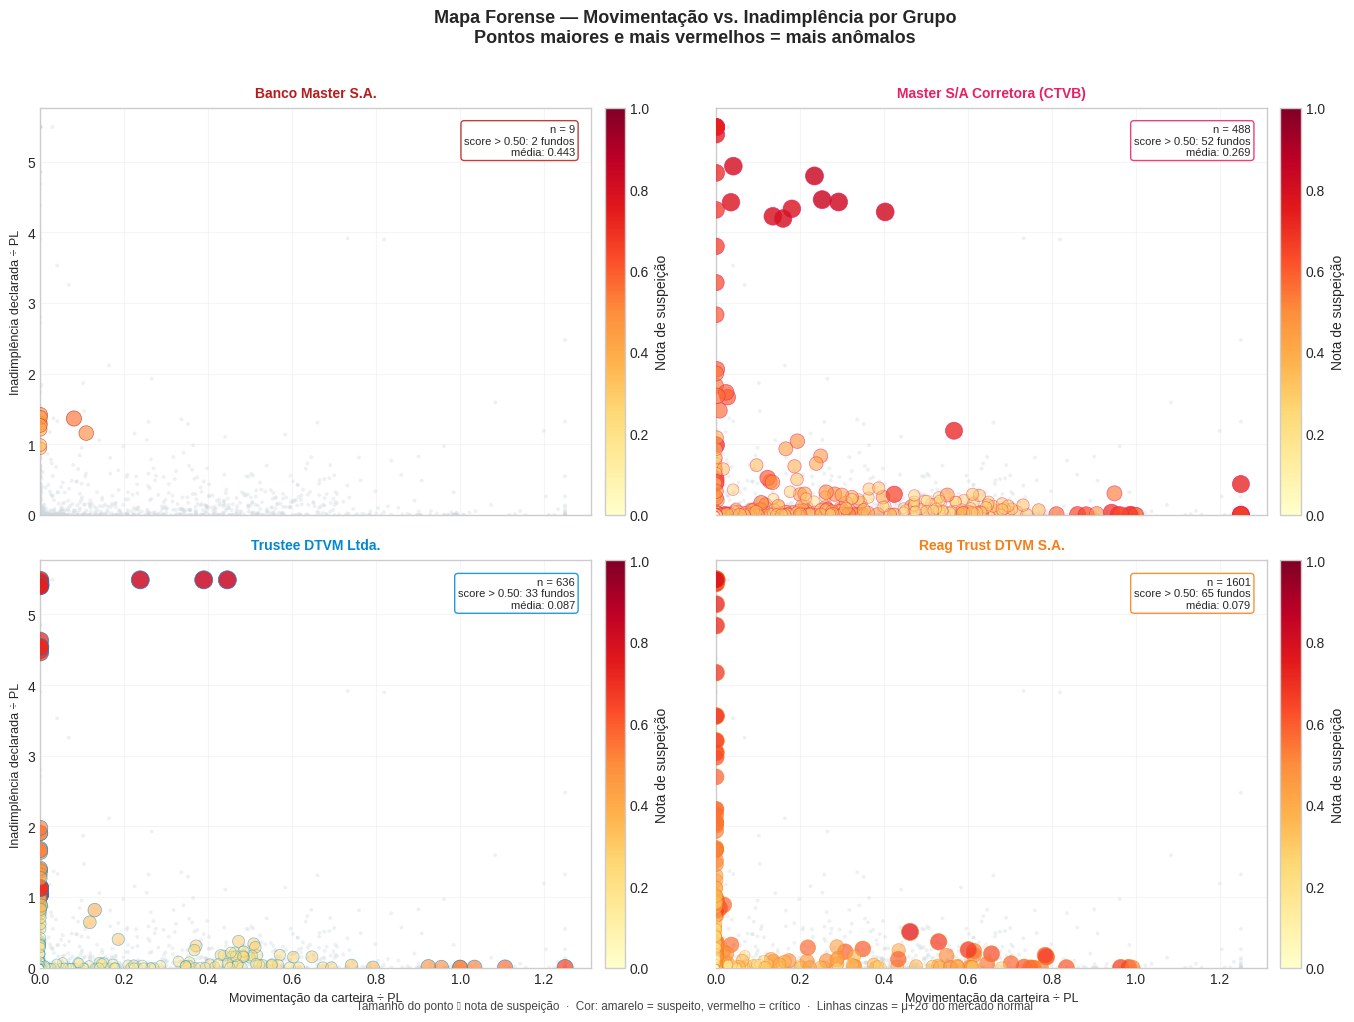

In [ ]:
# GRÁFICO 3 — Mapa Forense TM × TI (versão legível)
import matplotlib.pyplot as plt
import numpy as np

tm_p99 = 1.25
ti_p99 = 5.49
tm_mu  = df_master[df_master['grupo_economico'] == 'Mercado']['movimentacao_total_taxa'].mean()
ti_mu  = df_master[df_master['grupo_economico'] == 'Mercado']['taxa_inadimplencia'].mean()
tm_std = df_master[df_master['grupo_economico'] == 'Mercado']['movimentacao_total_taxa'].std()
ti_std = df_master[df_master['grupo_economico'] == 'Mercado']['taxa_inadimplencia'].std()

grupos_cfg = {
    'Banco Master S.A.'           : '#B71C1C',
    'Master S/A Corretora (CTVB)' : '#E91E63',
    'Trustee DTVM Ltda.'          : '#0288D1',
    'Reag Trust DTVM S.A.'        : '#F57F17',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (grupo, cor) in zip(axes, grupos_cfg.items()):

    # Mercado de fundo — cinza claro, pequeno
    merc = df_master[
        (df_master['grupo_economico'] == 'Mercado') &
        (df_master['anomaly_score'].notna())
    ].sample(1500, random_state=42)

    ax.scatter(
        merc['movimentacao_total_taxa'].clip(0, tm_p99),
        merc['taxa_inadimplencia'].clip(0, ti_p99),
        color='#CFD8DC', s=8, alpha=0.35,
        edgecolors='none', zorder=1, label='Mercado'
    )

    # Grupo investigado — tamanho e opacidade proporcionais ao score
    sub = df_master[
        (df_master['grupo_economico'] == grupo) &
        (df_master['anomaly_score'].notna())
    ].copy()

    if len(sub) == 0:
        ax.set_title(grupo, fontsize=10, fontweight='bold', color=cor)
        continue

    scores = sub['anomaly_score'].values
    tamanhos  = 20 + scores * 180   # pontos mais anômalos = maiores
    opacidade = 0.3 + scores * 0.65  # pontos mais anômalos = mais opacos

    sc = ax.scatter(
        sub['movimentacao_total_taxa'].clip(0, tm_p99),
        sub['taxa_inadimplencia'].clip(0, ti_p99),
        s=tamanhos, c=scores, cmap='YlOrRd',
        vmin=0, vmax=1, alpha=opacidade,
        edgecolors=cor, linewidth=0.5, zorder=4
    )

    # Linhas de referência μ+2σ do mercado
    ax.axvline(tm_mu + 2*tm_std, color='gray', linestyle='--',
               lw=1.0, alpha=0.6)
    ax.axhline(ti_mu + 2*ti_std, color='gray', linestyle=':',
               lw=1.0, alpha=0.6)

    # Zona de risco — quadrante superior direito
    ax.axvspan(tm_mu + 2*tm_std, tm_p99 * 1.05,
               ymin=(ti_mu + 2*ti_std) / (ti_p99 * 1.05),
               color=cor, alpha=0.06, zorder=0)

    # Estatísticas no canto
    n_alto = (scores > 0.50).sum()
    ax.text(0.97, 0.96,
            f'n = {len(sub)}\nscore > 0.50: {n_alto} fundos\nmédia: {scores.mean():.3f}',
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=cor, alpha=0.85))

    ax.set_title(grupo, fontsize=10, fontweight='bold', color=cor, pad=8)
    plt.colorbar(sc, ax=ax, label='Nota de suspeição', pad=0.02)

# Rótulos globais
for ax in axes[2:]:
    ax.set_xlabel('Movimentação da carteira ÷ PL', fontsize=9)
for ax in [axes[0], axes[2]]:
    ax.set_ylabel('Inadimplência declarada ÷ PL', fontsize=9)

# Legenda de tamanho
for ax in axes:
    ax.set_xlim(0, tm_p99 * 1.05)
    ax.set_ylim(0, ti_p99 * 1.05)
    ax.grid(alpha=0.18)

# Nota de leitura
fig.text(0.5, 0.01,
         'Tamanho do ponto ∝ nota de suspeição  ·  Cor: amarelo = suspeito, vermelho = crítico  ·  '
         'Linhas cinzas = μ+2σ do mercado normal',
         ha='center', fontsize=8.5, color='#444444')

fig.suptitle('Mapa Forense — Movimentação vs. Inadimplência por Grupo\n'
             'Pontos maiores e mais vermelhos = mais anômalos',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico3_mapa_forense_subplots.png',
            dpi=150, bbox_inches='tight')
plt.show()

- Cada ponto é um fundo em um mês. O eixo X mostra o quanto o fundo movimentou sua carteira de contratos naquele mês em relação ao seu tamanho (compras, recompras, substituições). O eixo Y mostra o quanto da carteira estava inadimplente. As linhas cinzas tracejadas marcam o limite de dois desvios-padrão acima da média do mercado normal — pontos além dessas linhas já estão fora do padrão esperado.
A cor e o tamanho de cada ponto indicam a nota de suspeição: pontos amarelos e pequenos são normais, pontos vermelhos e grandes são críticos. O fundo cinza claro em cada painel é o mercado de referência — serve para você enxergar onde o grupo investigado se posiciona em relação ao comportamento típico.
O que procurar: fundos no quadrante superior direito (alta movimentação E alta inadimplência) são os mais preocupantes. Fundos com alta movimentação mas inadimplência baixa (parte direita, parte de baixo) são o sinal clássico de mascaramento — estão girando a carteira para esconder contratos problemáticos antes de declará-los.

### Gráfico 4 — Distribuição das notas por grupo (violin + boxplot)


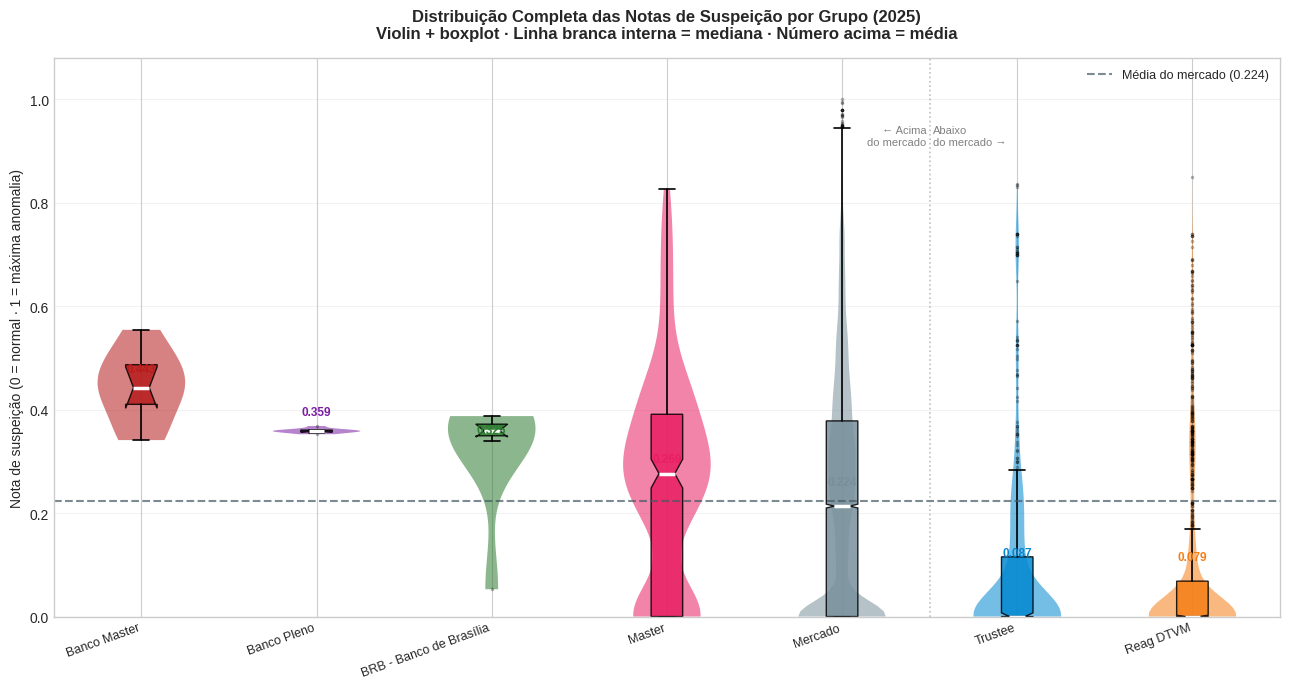

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(13, 7))

ordem = [
    'Banco Master S.A.', 'Banco Pleno S.A.',
    'BRB - Banco de Brasília S.A.', 'Master S/A Corretora (CTVB)',
    'Mercado',
    'Trustee DTVM Ltda.', 'Reag Trust DTVM S.A.',
]
cores = {
    'Banco Master S.A.'           : '#B71C1C',
    'Banco Pleno S.A.'            : '#7B1FA2',
    'BRB - Banco de Brasília S.A.': '#2E7D32',
    'Master S/A Corretora (CTVB)' : '#E91E63',
    'Mercado'                     : '#78909C',
    'Trustee DTVM Ltda.'          : '#0288D1',
    'Reag Trust DTVM S.A.'        : '#F57F17',
}

dados = [
    df_master[df_master['grupo_economico'] == g]['anomaly_score'].dropna().values
    for g in ordem
]

# Violin
vp = ax.violinplot(dados, positions=range(len(ordem)),
                   showmedians=False, showextrema=False)
for pc, grupo in zip(vp['bodies'], ordem):
    pc.set_facecolor(cores[grupo])
    pc.set_alpha(0.55)

# Boxplot sobreposto
bp = ax.boxplot(dados, positions=range(len(ordem)),
                patch_artist=True, notch=True, widths=0.18,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
for patch, grupo in zip(bp['boxes'], ordem):
    patch.set_facecolor(cores[grupo])
    patch.set_alpha(0.85)

# Linha de referência — média do mercado
media_merc = df_master[df_master['grupo_economico']=='Mercado']['anomaly_score'].mean()
ax.axhline(media_merc, color='#455A64', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Média do mercado ({media_merc:.3f})')

# Anotação das médias
for i, (grupo, dado) in enumerate(zip(ordem, dados)):
    if len(dado) == 0:
        continue
    media = np.mean(dado)
    ax.text(i, media + 0.03, f'{media:.3f}', ha='center', fontsize=8.5,
            fontweight='bold', color=cores[grupo])

# Divisor visual entre investigados e mercado
ax.axvline(4.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.5)
ax.text(4.52, 0.95, 'Abaixo\ndo mercado →', fontsize=8, color='gray', va='top')
ax.text(4.48, 0.95, '← Acima\ndo mercado', fontsize=8, color='gray', va='top', ha='right')

ax.set_xticks(range(len(ordem)))
ax.set_xticklabels(
    [g.replace(' DTVM Ltda.','').replace(' S.A.','').replace(' S/A Corretora (CTVB)','')
       .replace(' Trust','') for g in ordem],
    rotation=20, ha='right', fontsize=9
)
ax.set_ylabel('Nota de suspeição (0 = normal · 1 = máxima anomalia)', fontsize=10)
ax.set_title('Distribuição Completa das Notas de Suspeição por Grupo (2025)\n'
             'Violin + boxplot · Linha branca interna = mediana · Número acima = média',
             fontsize=12, fontweight='bold', pad=14)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.08)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico4_distribuicao_notas.png',
            dpi=150, bbox_inches='tight')
plt.show()

- Cada coluna é um grupo econômico. A forma do violino mostra onde a maioria das notas se concentra — quanto mais larga a coluna num certo nível, mais observações têm aquela nota. A caixa interna é o boxplot clássico: a linha branca é a mediana, a caixa vai do percentil 25 ao 75, e os traços externos mostram o alcance dos valores. O número acima de cada coluna é a média do grupo.
A linha tracejada horizontal é a média do mercado — serve como régua. Grupos acima dela estão sistematicamente mais suspeitos que o mercado normal. Grupos abaixo (Trustee e Reag) têm média baixa porque a maioria dos seus fundos não declara cedente, o que faz o modelo tratá-los como normais por falta de dado — mas repare que os violinos desses grupos têm uma cauda longa subindo até 0.60 e 0.62, que são os fundos individuais críticos detectados.